<a href="https://colab.research.google.com/github/eshika2004/DataPrepAI/blob/main/app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing libraries

In [41]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.4 MB/s eta 0:00:00


In [51]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    Image
)
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch

#Utility Functions

In [52]:
def print_header(title):
    print("\n")
    print("=" * 70)
    print(title.center(70))
    print("=" * 70)



def get_file_path():
    file_path = input("Enter the dataset path: ")
    return file_path



def get_valid_file_path():

    while True:

        file_path = get_file_path()

        is_valid, message = validate_file(file_path)

        if is_valid:
            return file_path

        print(f"\n{message}\n")



def validate_file(file_path):

    # Check if the file path is empty
    if not file_path.strip():
        return False, "File path cannot be empty."

    # Create a Path object
    path = Path(file_path)

    # Check if the file exists
    if not path.exists():
        return False, "File not found."

    # Supported file formats
    supported_extensions = {".csv", ".xlsx", ".xls"}

    # Check file extension
    if path.suffix.lower() not in supported_extensions:
        return False, (
            "Unsupported file format.\n"
            "Supported formats: .csv, .xlsx, .xls"
        )

    return True, None



def load_dataset(file_path):
    path = Path(file_path)
    try:

      if path.suffix.lower() == ".csv":
          df = pd.read_csv(file_path)

      else:
          df = pd.read_excel(file_path)

      return df, None

    except Exception as e:
        return None, f"Unable to load dataset.\n{e}"

#Module 1: Dataset Overview

In [53]:
def show_dataset_summary(df, file_path):

    print_header("DATASET SUMMARY")

    BYTES_PER_MB = 1024 * 1024

    memory = df.memory_usage(deep=True).sum() / BYTES_PER_MB

    numerical_cols = df.select_dtypes(include="number").shape[1]
    categorical_cols = df.select_dtypes(exclude="number").shape[1]

    summary = {
        "Dataset Name": Path(file_path).name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Memory Usage": f"{memory:.2f} MB",
        "Numerical Columns": numerical_cols,
        "Categorical Columns": categorical_cols
    }

    for key, value in summary.items():
        print(f"{key:<22}: {value}")

    return summary


def preview_dataset(df):

    print_header("DATASET PREVIEW")

    preview = df.head()

    print(preview)

    return preview

#Module 2: Data Quality Analysis

In [54]:
def analyze_missing_values(df):

    total_rows = len(df)

    missing_values = df.isnull().sum()

    missing_percentage = ((missing_values / total_rows) * 100).round(2)

    report = pd.DataFrame()

    report["Column"] = missing_values.index
    report["Missing Values"] = missing_values.values
    report["Missing Percentage (%)"] = missing_percentage.values

    status = []

    for value in missing_values:

        if value == 0:
            status.append("Clean")
        else:
            status.append("Missing")

    report["Status"] = status

    print_header("MISSING VALUE ANALYSIS")

    print(report.to_string(index=False))

    print("-" * 70)

    total_missing = missing_values.sum()

    columns_with_missing = (missing_values > 0).sum()

    clean_columns = (missing_values == 0).sum()

    dataset_missing_percentage = (
        total_missing / (df.shape[0] * df.shape[1])
    ) * 100

    summary = {
        "Total Missing Values": total_missing,
        "Columns with Missing Values": columns_with_missing,
        "Clean Columns": clean_columns,
        "Dataset Missing Percentage": round(dataset_missing_percentage, 2)
    }

    print("Summary")

    for key, value in summary.items():

        if "Percentage" in key:
            print(f"{key:<30}: {value:.2f}%")
        else:
            print(f"{key:<30}: {value}")

    return report, summary


def detect_outliers(df):

    numeric_cols = df.select_dtypes(include='number').columns

    outlier_counts = {}

    for col in numeric_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[col] < lower_bound) |
            (df[col] > upper_bound)
        ]

        outlier_counts[col] = len(outliers)

    # Create report
    report = pd.DataFrame()

    report["Column"] = outlier_counts.keys()
    report["Outlier Count"] = outlier_counts.values()

    # Add status
    status = []

    for count in outlier_counts.values():

        if count == 0:
            status.append("Clean")
        else:
            status.append("Outliers Detected")

    report["Status"] = status

    print_header("OUTLIER ANALYSIS")

    print(report.to_string(index=False))

    print("-" * 70)

    total_outliers = sum(outlier_counts.values())

    columns_with_outliers = sum(
        count > 0 for count in outlier_counts.values()
    )

    clean_columns = sum(
        count == 0 for count in outlier_counts.values()
    )

    summary = {
        "Total Outliers": total_outliers,
        "Columns with Outliers": columns_with_outliers,
        "Clean Columns": clean_columns
    }

    print("Summary")

    for key, value in summary.items():
        print(f"{key:<30}: {value}")

    return report, summary, outlier_counts


def suggest_missing_value_technique(df, outlier_counts):

    recommendations = []

    for col in df.columns:

        missing_count = df[col].isnull().sum()

        # Skip columns with no missing values
        if missing_count == 0:
            continue

        # Check if column is datetime
        is_datetime = pd.api.types.is_datetime64_any_dtype(df[col])

        # Check if column name suggests time/order
        time_keywords = [
            "date", "time", "timestamp",
            "year", "month", "day"
        ]

        is_time_column = any(
            keyword in col.lower()
            for keyword in time_keywords
        )

        # Numerical column
        if pd.api.types.is_numeric_dtype(df[col]):

            # Time-series / ordered data
            if is_datetime or is_time_column:

                technique = "Forward Fill / Backward Fill"
                reason = "Ordered or time-based data"

            # Numerical column with outliers
            elif outlier_counts.get(col, 0) > 0:

                technique = "Median Imputation"
                reason = "Outliers detected"

            # Numerical column without outliers
            else:

                technique = "Mean Imputation"
                reason = "No outliers detected"

        # Categorical column
        else:

            technique = "Mode Imputation"
            reason = "Categorical column"

        recommendations.append({
            "Column": col,
            "Missing Values": missing_count,
            "Recommended Technique": technique,
            "Reason": reason
        })

    print_header("MISSING VALUE RECOMMENDATIONS")

    if len(recommendations) == 0:

        print("No missing values found.")
        print("No imputation required.")

        return pd.DataFrame()

    recommendation_report = pd.DataFrame(recommendations)

    print(recommendation_report.to_string(index=False))

    return recommendation_report


def analyze_duplicates(df):

    duplicate_rows = df.duplicated(keep=False)

    duplicate_records = df[duplicate_rows]

    duplicate_count = len(duplicate_records)

    total_rows = len(df)

    duplicate_percentage = round(
        (duplicate_count / total_rows) * 100, 2
    )

    non_duplicate_rows = total_rows - duplicate_count

    report = pd.DataFrame()

    report["Metric"] = [
        "Total Rows",
        "Duplicate Rows",
        "Non-Duplicate Rows",
        "Duplicate Percentage (%)"
    ]

    report["Value"] = [
        total_rows,
        duplicate_count,
        non_duplicate_rows,
        duplicate_percentage
    ]

    print_header("DUPLICATE ANALYSIS")

    print(report.to_string(index=False))

    summary = {
        "Total Rows": total_rows,
        "Duplicate Rows": duplicate_count,
        "Non-Duplicate Rows": non_duplicate_rows,
        "Duplicate Percentage": duplicate_percentage
    }

    return report, summary


def detect_constant_columns(df):

    constant_columns = []

    for col in df.columns:

        unique_count = df[col].nunique()

        if unique_count == 1:

            constant_columns.append({
                "Column": col,
                "Unique Values": unique_count,
                "Value": df[col].dropna().iloc[0],
                "Status": "Constant"
            })

    print_header("CONSTANT COLUMN ANALYSIS")

    if len(constant_columns) == 0:

        print("No constant columns detected.")

        return pd.DataFrame()

    report = pd.DataFrame(constant_columns)

    print(report.to_string(index=False))

    print("-" * 70)

    print(f"Total Constant Columns : {len(report)}")

    return report

# Module 3: Statistical Analysis

In [55]:
def analyze_numerical_statistics(df):

    numeric_cols = df.select_dtypes(include="number").columns

    report = pd.DataFrame()

    report["Column"] = numeric_cols

    report["Count"] = [
        df[col].count()
        for col in numeric_cols
    ]

    report["Mean"] = [
        df[col].mean()
        for col in numeric_cols
    ]

    report["Median"] = [
        df[col].median()
        for col in numeric_cols
    ]

    report["Standard Deviation"] = [
        df[col].std()
        for col in numeric_cols
    ]

    report["Minimum"] = [
        df[col].min()
        for col in numeric_cols
    ]

    report["Q1"] = [
        df[col].quantile(0.25)
        for col in numeric_cols
    ]

    report["Q3"] = [
        df[col].quantile(0.75)
        for col in numeric_cols
    ]

    report["Maximum"] = [
        df[col].max()
        for col in numeric_cols
    ]

    report["Range"] = [
        df[col].max() - df[col].min()
        for col in numeric_cols
    ]

    print_header("NUMERICAL STATISTICAL ANALYSIS")

    print(report.round(2).to_string(index=False))

    return report


def analyze_categorical_statistics(df):

    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns

    report = pd.DataFrame()

    report["Column"] = categorical_cols

    report["Count"] = [
        df[col].count()
        for col in categorical_cols
    ]

    report["Unique Values"] = [
        df[col].nunique()
        for col in categorical_cols
    ]

    report["Most Frequent Value"] = [
        df[col].mode().iloc[0]
        if not df[col].mode().empty
        else "N/A"
        for col in categorical_cols
    ]

    report["Frequency"] = [
        df[col].value_counts().iloc[0]
        if not df[col].value_counts().empty
        else 0
        for col in categorical_cols
    ]

    print_header("CATEGORICAL STATISTICAL ANALYSIS")

    if len(categorical_cols) == 0:

        print("No categorical columns detected.")

        return pd.DataFrame()

    print(report.to_string(index=False))

    return report

# Module 4:Distribution Analysis

In [56]:
def analyze_numerical_distribution(df):

    numeric_cols = df.select_dtypes(include="number").columns

    if len(numeric_cols) == 0:

        print_header("NUMERICAL DISTRIBUTION ANALYSIS")

        print("No numerical columns detected.")

        return

    print_header("NUMERICAL DISTRIBUTION ANALYSIS")

    for col in numeric_cols:

        print(f"\nDistribution of: {col}")

        print("-" * 50)

        print(f"Mean   : {df[col].mean():.2f}")
        print(f"Median : {df[col].median():.2f}")
        print(f"Skewness : {df[col].skew():.2f}")

        plt.figure(figsize=(8, 5))

        plt.hist(
            df[col].dropna(),
            bins=10,
            edgecolor="black"
        )

        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

        plt.show()


def analyze_categorical_distribution(df):

    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns

    if len(categorical_cols) == 0:

        print_header("CATEGORICAL DISTRIBUTION ANALYSIS")

        print("No categorical columns detected.")

        return

    print_header("CATEGORICAL DISTRIBUTION ANALYSIS")

    for col in categorical_cols:

        print(f"\nDistribution of: {col}")

        print("-" * 50)

        value_counts = df[col].value_counts()

        print(value_counts.to_string())

        plt.figure(figsize=(8, 5))

        value_counts.plot(kind="bar")

        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

        plt.xticks(rotation=45)

        plt.tight_layout()

        plt.show()

# Module 5:Correlation Analysis

In [57]:
def analyze_correlation(df):

    numeric_cols = df.select_dtypes(include="number").columns

    print_header("CORRELATION ANALYSIS")

    if len(numeric_cols) < 2:

        print("At least two numerical columns are required.")

        return pd.DataFrame()

    correlation_matrix = df[numeric_cols].corr()

    print(correlation_matrix.round(2).to_string())

    return correlation_matrix


def find_strongest_relationships(correlation_matrix):

    if correlation_matrix.empty:

        return

    relationships = []

    columns = correlation_matrix.columns

    for i in range(len(columns)):

        for j in range(i + 1, len(columns)):

            col1 = columns[i]
            col2 = columns[j]

            correlation = correlation_matrix.loc[col1, col2]

            relationships.append({
                "Column 1": col1,
                "Column 2": col2,
                "Correlation": correlation
            })

    relationship_report = pd.DataFrame(relationships)

    strongest_positive = relationship_report.loc[
        relationship_report["Correlation"].idxmax()
    ]

    strongest_negative = relationship_report.loc[
        relationship_report["Correlation"].idxmin()
    ]

    weakest_relationship = relationship_report.loc[
        relationship_report["Correlation"].abs().idxmin()
    ]

    print_header("STRONGEST RELATIONSHIPS")

    print(
        f"Strongest Positive : "
        f"{strongest_positive['Column 1']} ↔ "
        f"{strongest_positive['Column 2']} "
        f"({strongest_positive['Correlation']:.2f})"
    )

    print(
        f"Strongest Negative : "
        f"{strongest_negative['Column 1']} ↔ "
        f"{strongest_negative['Column 2']} "
        f"({strongest_negative['Correlation']:.2f})"
    )

    print(
        f"Weakest Relationship : "
        f"{weakest_relationship['Column 1']} ↔ "
        f"{weakest_relationship['Column 2']} "
        f"({weakest_relationship['Correlation']:.2f})"
    )

    return relationship_report


def show_correlation_heatmap(correlation_matrix):

    if correlation_matrix.empty:

        return

    print_header("CORRELATION HEATMAP")

    plt.figure(figsize=(10, 7))

    plt.imshow(
        correlation_matrix,
        aspect="auto"
    )

    plt.colorbar(label="Correlation")

    plt.xticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(correlation_matrix.columns)),
        correlation_matrix.columns
    )

    plt.title("Correlation Heatmap")

    plt.tight_layout()

    plt.show()

# Report generation

In [63]:
def generate_pdf_report(
    file_path,
    df,
    dataset_summary,
    dataset_preview,
    missing_report,
    missing_summary,
    duplicate_report,
    duplicate_summary,
    outlier_report,
    outlier_summary,
    missing_recommendations,
    constant_report,
    numerical_statistics,
    categorical_statistics,
    correlation_matrix,
    relationship_report
):

    pdf_file = "DataPrepAI_Report.pdf"

    doc = SimpleDocTemplate(
        pdf_file,
        pagesize=A4,
        rightMargin=40,
        leftMargin=40,
        topMargin=40,
        bottomMargin=40
    )

    styles = getSampleStyleSheet()

    title_style = styles["Title"]
    heading_style = styles["Heading2"]
    subheading_style = styles["Heading3"]
    normal_style = styles["BodyText"]

    elements = []


    # ========================================================
    # TITLE
    # ========================================================

    elements.append(
        Paragraph("DataPrepAI", title_style)
    )

    elements.append(
        Paragraph(
            "Dataset Analysis Report",
            heading_style
        )
    )

    elements.append(Spacer(1, 10))

    elements.append(
        Paragraph(
            f"<b>Dataset:</b> {file_path}",
            normal_style
        )
    )

    elements.append(Spacer(1, 20))


    # ========================================================
    # MODULE 1 – DATASET OVERVIEW
    # ========================================================

    elements.append(
        Paragraph(
            "1. Dataset Overview",
            heading_style
        )
    )

    elements.append(Spacer(1, 10))

    overview_data = [
        ["Metric", "Value"]
    ]

    for key, value in dataset_summary.items():

        overview_data.append([
            str(key),
            str(value)
        ])

    overview_table = Table(
        overview_data,
        colWidths=[220, 250]
    )

    overview_table.setStyle(
        TableStyle([
            ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
            ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ])
    )

    elements.append(overview_table)

    elements.append(Spacer(1, 15))


    # Dataset Preview

    elements.append(
        Paragraph(
            "Dataset Preview",
            subheading_style
        )
    )

    elements.append(Spacer(1, 8))

    preview_data = [
        list(dataset_preview.columns)
    ]

    for row in dataset_preview.values.tolist():

        preview_data.append([
            str(value)
            for value in row
        ])

    preview_table = Table(
        preview_data,
        repeatRows=1
    )

    preview_table.setStyle(
        TableStyle([
            ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
            ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("FONTSIZE", (0, 0), (-1, -1), 6),
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
        ])
    )

    elements.append(preview_table)

    elements.append(Spacer(1, 25))


    # ========================================================
    # MODULE 2 – DATA QUALITY ANALYSIS
    # ========================================================

    elements.append(
        Paragraph(
            "2. Data Quality Analysis",
            heading_style
        )
    )

    elements.append(Spacer(1, 10))


    # ---------------- Missing Values ----------------

    elements.append(
        Paragraph(
            "Missing Value Analysis",
            subheading_style
        )
    )

    missing_data = [
        list(missing_report.columns)
    ]

    for row in missing_report.values.tolist():

        missing_data.append([
            str(value)
            for value in row
        ])

    missing_table = Table(
        missing_data,
        repeatRows=1
    )

    missing_table.setStyle(
        TableStyle([
            ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
            ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("FONTSIZE", (0, 0), (-1, -1), 7),
        ])
    )

    elements.append(missing_table)

    elements.append(Spacer(1, 8))

    elements.append(
        Paragraph(
            f"<b>Total Missing Values:</b> "
            f"{missing_summary['Total Missing Values']}<br/>"
            f"<b>Columns with Missing Values:</b> "
            f"{missing_summary['Columns with Missing Values']}<br/>"
            f"<b>Dataset Missing Percentage:</b> "
            f"{missing_summary['Dataset Missing Percentage']:.2f}%",
            normal_style
        )
    )

    elements.append(Spacer(1, 15))


    # ---------------- Duplicate Analysis ----------------

    elements.append(
        Paragraph(
            "Duplicate Analysis",
            subheading_style
        )
    )

    duplicate_data = [
        list(duplicate_report.columns)
    ]

    for row in duplicate_report.values.tolist():

        duplicate_data.append([
            str(value)
            for value in row
        ])

    duplicate_table = Table(
        duplicate_data,
        repeatRows=1
    )

    duplicate_table.setStyle(
        TableStyle([
            ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
            ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("FONTSIZE", (0, 0), (-1, -1), 7),
        ])
    )

    elements.append(duplicate_table)

    elements.append(Spacer(1, 15))


    # ---------------- Outlier Analysis ----------------

    elements.append(
        Paragraph(
            "Outlier Analysis",
            subheading_style
        )
    )

    outlier_data = [
        list(outlier_report.columns)
    ]

    for row in outlier_report.values.tolist():

        outlier_data.append([
            str(value)
            for value in row
        ])

    outlier_table = Table(
        outlier_data,
        repeatRows=1
    )

    outlier_table.setStyle(
        TableStyle([
            ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
            ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
            ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
            ("FONTSIZE", (0, 0), (-1, -1), 7),
        ])
    )

    elements.append(outlier_table)

    elements.append(Spacer(1, 8))

    elements.append(
        Paragraph(
            f"<b>Total Outliers:</b> "
            f"{outlier_summary['Total Outliers']}<br/>"
            f"<b>Columns with Outliers:</b> "
            f"{outlier_summary['Columns with Outliers']}<br/>"
            f"<b>Clean Columns:</b> "
            f"{outlier_summary['Clean Columns']}",
            normal_style
        )
    )

    elements.append(Spacer(1, 15))


    # ---------------- Constant Columns ----------------

    elements.append(
        Paragraph(
            "Constant Column Analysis",
            subheading_style
        )
    )

    if constant_report.empty:

        elements.append(
            Paragraph(
                "No constant columns detected.",
                normal_style
            )
        )

    else:

        constant_data = [
            list(constant_report.columns)
        ]

        for row in constant_report.values.tolist():

            constant_data.append([
                str(value)
                for value in row
            ])

        constant_table = Table(
            constant_data,
            repeatRows=1
        )

        constant_table.setStyle(
            TableStyle([
                ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
                ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
                ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
                ("FONTSIZE", (0, 0), (-1, -1), 7),
            ])
        )

        elements.append(constant_table)

    elements.append(Spacer(1, 15))


    # ---------------- Missing Value Recommendations ----------------

    elements.append(
        Paragraph(
            "Missing Value Recommendations",
            subheading_style
        )
    )

    if missing_recommendations.empty:

        elements.append(
            Paragraph(
                "No missing values found. No imputation required.",
                normal_style
            )
        )

    else:

        recommendation_data = [
            list(missing_recommendations.columns)
        ]

        for row in missing_recommendations.values.tolist():

            recommendation_data.append([
                str(value)
                for value in row
            ])

        recommendation_table = Table(
            recommendation_data,
            repeatRows=1
        )

        recommendation_table.setStyle(
            TableStyle([
                ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
                ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
                ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
                ("FONTSIZE", (0, 0), (-1, -1), 7),
            ])
        )

        elements.append(recommendation_table)

    elements.append(Spacer(1, 25))


    # ========================================================
    # MODULE 3 – STATISTICAL ANALYSIS
    # ========================================================

    elements.append(
        Paragraph(
            "3. Statistical Analysis",
            heading_style
        )
    )

    elements.append(Spacer(1, 10))


    # ---------------- Numerical Statistics ----------------

    elements.append(
        Paragraph(
            "Numerical Statistical Analysis",
            subheading_style
        )
    )

    if numerical_statistics.empty:

        elements.append(
            Paragraph(
                "No numerical columns detected.",
                normal_style
            )
        )

    else:

        numerical_data = [
            list(numerical_statistics.columns)
        ]

        for row in numerical_statistics.round(2).values.tolist():

            numerical_data.append([
                str(value)
                for value in row
            ])

        numerical_table = Table(
            numerical_data,
            repeatRows=1
        )

        numerical_table.setStyle(
            TableStyle([
                ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
                ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
                ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
                ("FONTSIZE", (0, 0), (-1, -1), 6),
            ])
        )

        elements.append(numerical_table)

    elements.append(Spacer(1, 15))


    # ---------------- Categorical Statistics ----------------

    elements.append(
        Paragraph(
            "Categorical Statistical Analysis",
            subheading_style
        )
    )

    if categorical_statistics.empty:

        elements.append(
            Paragraph(
                "No categorical columns detected.",
                normal_style
            )
        )

    else:

        categorical_data = [
            list(categorical_statistics.columns)
        ]

        for row in categorical_statistics.values.tolist():

            categorical_data.append([
                str(value)
                for value in row
            ])

        categorical_table = Table(
            categorical_data,
            repeatRows=1
        )

        categorical_table.setStyle(
            TableStyle([
                ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
                ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
                ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
                ("FONTSIZE", (0, 0), (-1, -1), 7),
            ])
        )

        elements.append(categorical_table)

    elements.append(Spacer(1, 25))


    # ========================================================
    # MODULE 4 – DISTRIBUTION ANALYSIS
    # ========================================================

    elements.append(
        Paragraph(
            "4. Distribution Analysis",
            heading_style
        )
    )

    elements.append(Spacer(1, 10))


    # ---------------- Numerical Distributions ----------------

    numeric_cols = df.select_dtypes(include="number").columns

    if len(numeric_cols) == 0:

        elements.append(
            Paragraph(
                "No numerical columns detected.",
                normal_style
            )
        )

    else:

        elements.append(
            Paragraph(
                "Numerical Distributions",
                subheading_style
            )
        )

        for col in numeric_cols:

            elements.append(
                Paragraph(
                    f"<b>{col}</b>",
                    normal_style
                )
            )

            plt.figure(figsize=(7, 4))

            plt.hist(
                df[col].dropna(),
                bins=10,
                edgecolor="black"
            )

            plt.title(f"Distribution of {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")

            plt.tight_layout()

            image_file = f"temp_{col}_distribution.png"

            plt.savefig(
                image_file,
                dpi=150,
                bbox_inches="tight"
            )

            plt.close()

            elements.append(
                Image(
                    image_file,
                    width=450,
                    height=250
                )
            )

            elements.append(Spacer(1, 10))


    # ---------------- Categorical Distributions ----------------

    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns

    if len(categorical_cols) > 0:

        elements.append(
            Paragraph(
                "Categorical Distributions",
                subheading_style
            )
        )

        for col in categorical_cols:

            value_counts = df[col].value_counts()

            plt.figure(figsize=(7, 4))

            value_counts.plot(kind="bar")

            plt.title(f"Distribution of {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")

            plt.xticks(rotation=45)

            plt.tight_layout()

            image_file = f"temp_{col}_distribution.png"

            plt.savefig(
                image_file,
                dpi=150,
                bbox_inches="tight"
            )

            plt.close()

            elements.append(
                Image(
                    image_file,
                    width=450,
                    height=250
                )
            )

            elements.append(Spacer(1, 10))

    elements.append(Spacer(1, 15))


    # ========================================================
    # MODULE 5 – RELATIONSHIP ANALYSIS
    # ========================================================

    elements.append(
        Paragraph(
            "5. Relationship / Correlation Analysis",
            heading_style
        )
    )

    elements.append(Spacer(1, 10))


    # ---------------- Correlation Matrix ----------------

    elements.append(
        Paragraph(
            "Correlation Matrix",
            subheading_style
        )
    )

    if correlation_matrix.empty:

        elements.append(
            Paragraph(
                "At least two numerical columns are required.",
                normal_style
            )
        )

    else:

        correlation_data = [
            [""] + list(correlation_matrix.columns)
        ]

        for index, row in correlation_matrix.round(2).iterrows():

            correlation_data.append(
                [str(index)] +
                [str(value) for value in row]
            )

        correlation_table = Table(
            correlation_data,
            repeatRows=1
        )

        correlation_table.setStyle(
            TableStyle([
                ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
                ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
                ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
                ("FONTSIZE", (0, 0), (-1, -1), 6),
            ])
        )

        elements.append(correlation_table)

        elements.append(Spacer(1, 15))


        # ---------------- Strongest Relationships ----------------

        elements.append(
            Paragraph(
                "Strongest Relationships",
                subheading_style
            )
        )

        strongest_positive = relationship_report.loc[
            relationship_report["Correlation"].idxmax()
        ]

        strongest_negative = relationship_report.loc[
            relationship_report["Correlation"].idxmin()
        ]

        weakest_relationship = relationship_report.loc[
            relationship_report["Correlation"].abs().idxmin()
        ]

        relationship_summary = [
            ["Relationship", "Columns", "Correlation"],

            [
                "Strongest Positive",
                f"{strongest_positive['Column 1']} ↔ "
                f"{strongest_positive['Column 2']}",
                f"{strongest_positive['Correlation']:.2f}"
            ],

            [
                "Strongest Negative",
                f"{strongest_negative['Column 1']} ↔ "
                f"{strongest_negative['Column 2']}",
                f"{strongest_negative['Correlation']:.2f}"
            ],

            [
                "Weakest",
                f"{weakest_relationship['Column 1']} ↔ "
                f"{weakest_relationship['Column 2']}",
                f"{weakest_relationship['Correlation']:.2f}"
            ]
        ]

        relationship_table = Table(
            relationship_summary,
            repeatRows=1
        )

        relationship_table.setStyle(
            TableStyle([
                ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
                ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
                ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
                ("FONTSIZE", (0, 0), (-1, -1), 7),
            ])
        )

        elements.append(relationship_table)

        elements.append(Spacer(1, 15))


        # ---------------- Heatmap ----------------

        elements.append(
            Paragraph(
                "Correlation Heatmap",
                subheading_style
            )
        )

        plt.figure(figsize=(8, 6))

        plt.imshow(
            correlation_matrix,
            aspect="auto"
        )

        plt.colorbar(label="Correlation")

        plt.xticks(
            range(len(correlation_matrix.columns)),
            correlation_matrix.columns,
            rotation=45,
            ha="right"
        )

        plt.yticks(
            range(len(correlation_matrix.columns)),
            correlation_matrix.columns
        )

        plt.title("Correlation Heatmap")

        plt.tight_layout()

        heatmap_file = "temp_correlation_heatmap.png"

        plt.savefig(
            heatmap_file,
            dpi=150,
            bbox_inches="tight"
        )

        plt.close()

        elements.append(
            Image(
                heatmap_file,
                width=450,
                height=350
            )
        )


    # ========================================================
    # END OF REPORT
    # ========================================================

    elements.append(Spacer(1, 25))

    elements.append(
        Paragraph(
            "End of DataPrepAI Report",
            heading_style
        )
    )

    doc.build(elements)

    print("\nPDF report generated successfully.")
    print(f"File: {pdf_file}")

    return pdf_file


#Main

Enter the dataset path: /content/Diabetes Missing Data.csv


                           DATASET SUMMARY                            
Dataset Name          : Diabetes Missing Data.csv
Rows                  : 768
Columns               : 9
Memory Usage          : 0.05 MB
Numerical Columns     : 9
Categorical Columns   : 0


                           DATASET PREVIEW                            
   Pregnant  Glucose  Diastolic_BP  Skin_Fold  Serum_Insulin   BMI  \
0         6    148.0          72.0       35.0            NaN  33.6   
1         1     85.0          66.0       29.0            NaN  26.6   
2         8    183.0          64.0        NaN            NaN  23.3   
3         1     89.0          66.0       23.0           94.0  28.1   
4         0    137.0          40.0       35.0          168.0  43.1   

   Diabetes_Pedigree  Age  Class  
0              0.627   50      1  
1              0.351   31      0  
2              0.672   32      1  
3              0.167   21      0  
4          

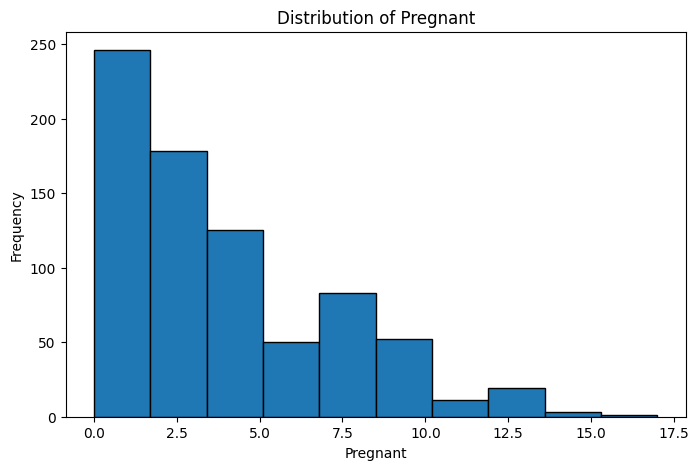


Distribution of: Glucose
--------------------------------------------------
Mean   : 121.69
Median : 117.00
Skewness : 0.53


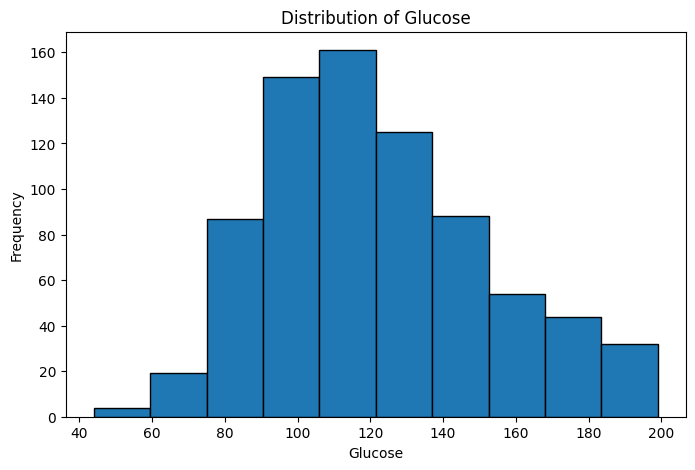


Distribution of: Diastolic_BP
--------------------------------------------------
Mean   : 72.41
Median : 72.00
Skewness : 0.13


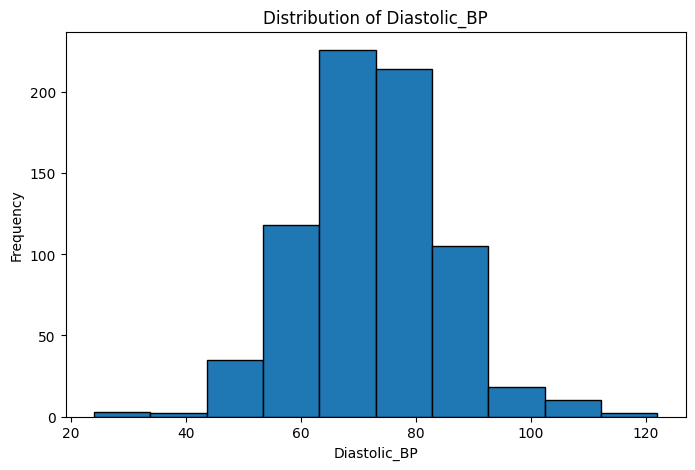


Distribution of: Skin_Fold
--------------------------------------------------
Mean   : 29.15
Median : 29.00
Skewness : 0.69


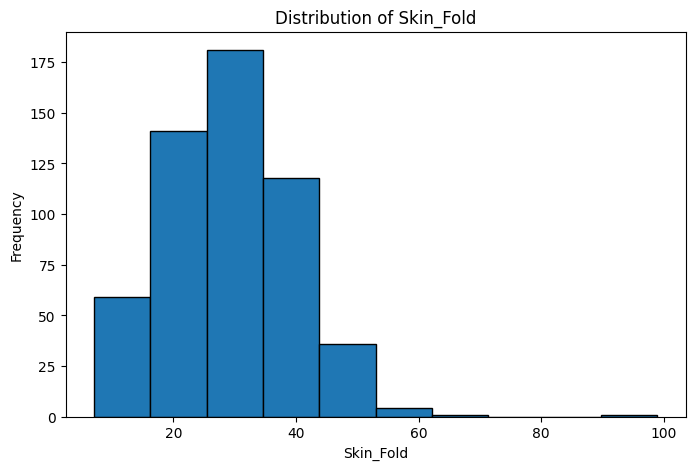


Distribution of: Serum_Insulin
--------------------------------------------------
Mean   : 155.55
Median : 125.00
Skewness : 2.17


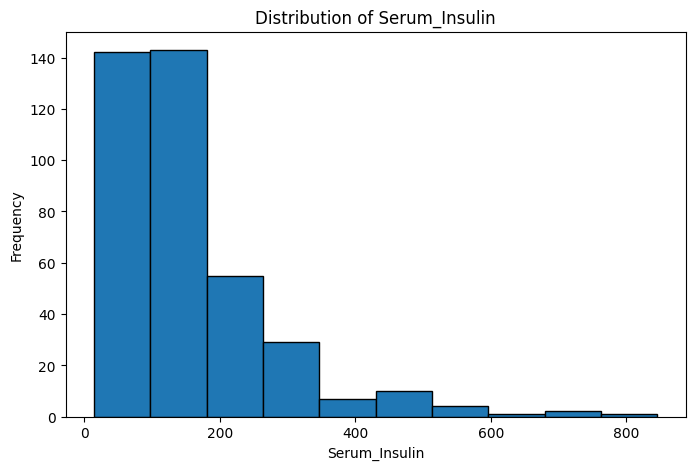


Distribution of: BMI
--------------------------------------------------
Mean   : 32.46
Median : 32.30
Skewness : 0.59


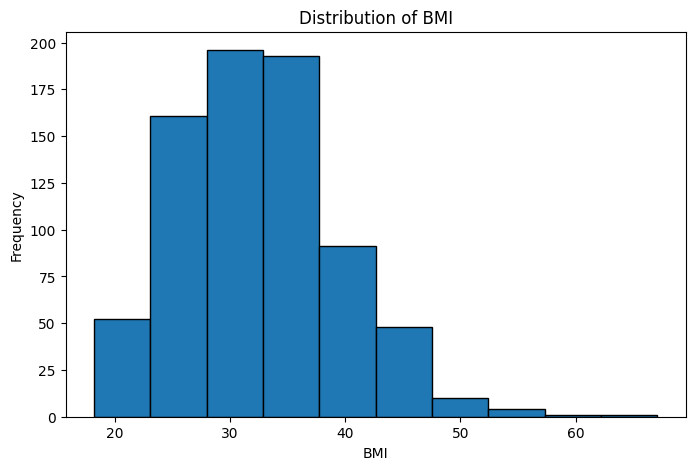


Distribution of: Diabetes_Pedigree
--------------------------------------------------
Mean   : 0.47
Median : 0.37
Skewness : 1.92


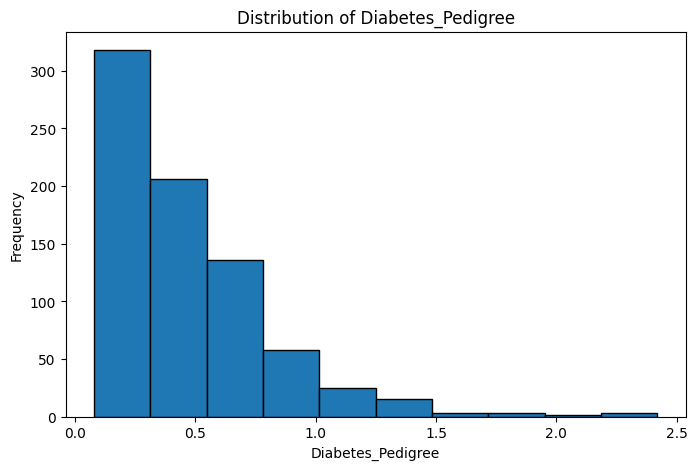


Distribution of: Age
--------------------------------------------------
Mean   : 33.24
Median : 29.00
Skewness : 1.13


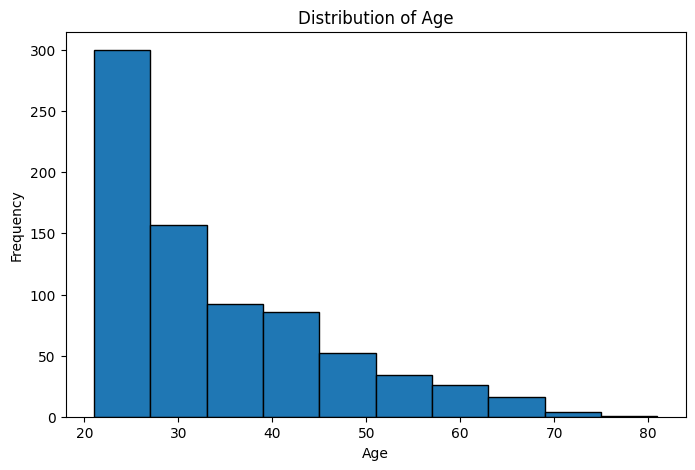


Distribution of: Class
--------------------------------------------------
Mean   : 0.35
Median : 0.00
Skewness : 0.64


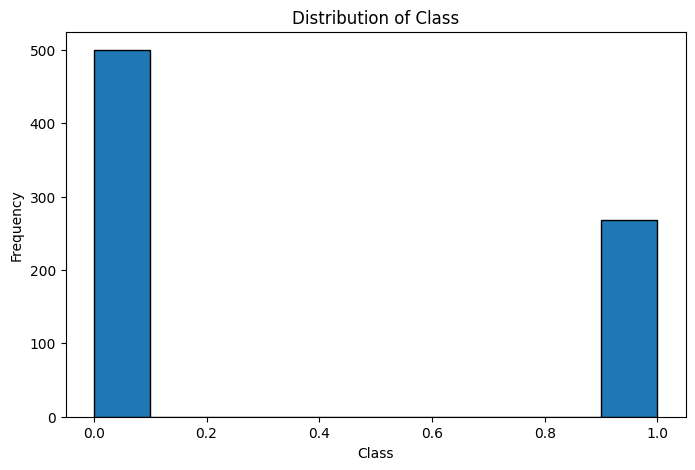



                  CATEGORICAL DISTRIBUTION ANALYSIS                   
No categorical columns detected.


                         CORRELATION ANALYSIS                         
                   Pregnant  Glucose  Diastolic_BP  Skin_Fold  Serum_Insulin   BMI  Diabetes_Pedigree   Age  Class
Pregnant               1.00     0.13          0.21       0.10           0.08  0.02              -0.03  0.54   0.22
Glucose                0.13     1.00          0.22       0.23           0.58  0.23               0.14  0.27   0.49
Diastolic_BP           0.21     0.22          1.00       0.23           0.10  0.29              -0.00  0.33   0.17
Skin_Fold              0.10     0.23          0.23       1.00           0.18  0.65               0.12  0.17   0.26
Serum_Insulin          0.08     0.58          0.10       0.18           1.00  0.23               0.13  0.22   0.30
BMI                    0.02     0.23          0.29       0.65           0.23  1.00               0.16  0.03   0.31
Diabetes_Pedigre

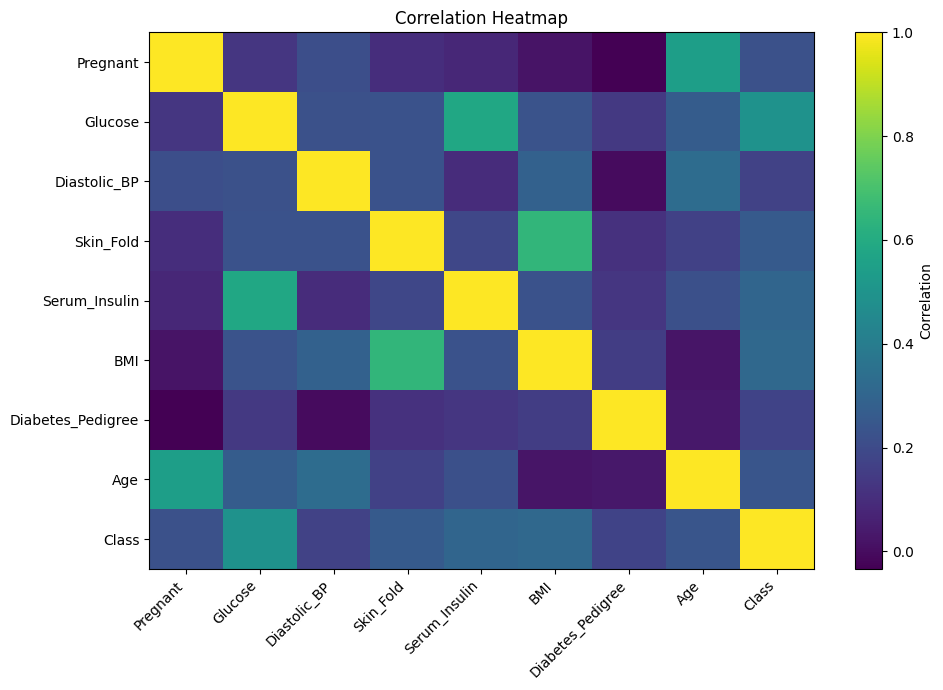


PDF report generated successfully.
File: DataPrepAI_Report.pdf


In [65]:
def main():

    # ========================================================
    # LOAD DATASET
    # ========================================================

    file_path = get_valid_file_path()

    df, message = load_dataset(file_path)

    if df is None:
        print(message)
        return


    # ========================================================
    # MODULE 1 – DATASET OVERVIEW
    # ========================================================

    dataset_summary = show_dataset_summary(
        df,
        file_path
    )

    dataset_preview = preview_dataset(df)


    # ========================================================
    # MODULE 2 – DATA QUALITY ANALYSIS
    # ========================================================

    missing_report, missing_summary = analyze_missing_values(
        df
    )

    duplicate_report, duplicate_summary = analyze_duplicates(
        df
    )

    outlier_report, outlier_summary, outlier_counts = detect_outliers(
        df
    )

    missing_recommendations = suggest_missing_value_technique(
        df,
        outlier_counts
    )

    constant_report = detect_constant_columns(
        df
    )


    # ========================================================
    # MODULE 3 – STATISTICAL ANALYSIS
    # ========================================================

    numerical_statistics = analyze_numerical_statistics(
        df
    )

    categorical_statistics = analyze_categorical_statistics(
        df
    )


    # ========================================================
    # MODULE 4 – DISTRIBUTION ANALYSIS
    # ========================================================

    analyze_numerical_distribution(
        df
    )

    analyze_categorical_distribution(
        df
    )


    # ========================================================
    # MODULE 5 – RELATIONSHIP / CORRELATION ANALYSIS
    # ========================================================

    correlation_matrix = analyze_correlation(
        df
    )

    relationship_report = find_strongest_relationships(
        correlation_matrix
    )

    show_correlation_heatmap(
        correlation_matrix
    )


    # ========================================================
    # FINAL REPORT – PDF GENERATION
    # ========================================================

    pdf_file = generate_pdf_report(
        file_path,
        df,
        dataset_summary,
        dataset_preview,
        missing_report,
        missing_summary,
        duplicate_report,
        duplicate_summary,
        outlier_report,
        outlier_summary,
        missing_recommendations,
        constant_report,
        numerical_statistics,
        categorical_statistics,
        correlation_matrix,
        relationship_report
    )


# ============================================================
# PROGRAM START
# ============================================================

if __name__ == "__main__":
    main()
